# 06 - NLI Contradiction Judgment, Chunk-Level (ContraDoc)

Score every candidate chunk pair from step 05 with **two** NLI models and compare:

- **NLI-Base**: `cross-encoder/nli-deberta-v3-base` off-the-shelf (3-class softmax over `[contradiction, entailment, neutral]`).
- **NLI-Fine-tuned**: same backbone, head replaced with a 2-class binary classifier (`0 = not_contradiction`, `1 = contradiction`), fine-tuned in `06_NLI_finetune_ContraDoc.ipynb` on the leakage-controlled splits prepared in `nli_finetune_data.ipynb`.

**Leakage discipline.** The fine-tuned model was trained on `nli_train.csv` / `nli_val.csv` whose `base_doc_id`s are disjoint from the 150 balanced docs that produced `chunk_candidates.jsonl`. The eval cells below re-assert this at runtime so any future regeneration of the splits is caught immediately.

**Input:** `data/processed/ContraDoc/chunk_candidates.jsonl` (output of step 05)
**Fine-tuned weights:** `../fine-tuning/models/nli_binary/`
**Output:** `data/processed/ContraDoc/nli_predictions.jsonl` - one row per candidate carrying both `nli_base_*` and `nli_ft_*` scores.

In [1]:
import csv
import json
from collections import defaultdict
from pathlib import Path

import numpy as np
import torch
from sentence_transformers import CrossEncoder
from transformers import AutoModelForSequenceClassification, AutoTokenizer

INPUT_PATH = Path("data/processed/ContraDoc/chunk_candidates.jsonl")
OUTPUT_PATH = Path("data/processed/ContraDoc/nli_predictions.jsonl")
TRAIN_CSV = Path("data/processed/ContraDoc/nli/nli_train.csv")
VAL_CSV   = Path("data/processed/ContraDoc/nli/nli_val.csv")

NLI_BASE_MODEL = "cross-encoder/nli-deberta-v3-base"
NLI_FT_MODEL_DIR = Path("../fine-tuning/models/nli_binary")
BATCH_SIZE = 32
MAX_LEN = 256

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

device: cuda


## Load chunk-pair candidates and assert no train/eval leakage

The fine-tuned model trained on `nli_train.csv` + `nli_val.csv`. The eval set
`chunk_candidates.jsonl` comes from the 150 balanced docs (notebook 01's
held-out test pool). `base_doc_id` must be disjoint between training data and
the eval candidate pool.

In [2]:
candidates = [json.loads(line) for line in INPUT_PATH.open(encoding="utf-8")]
print(f"Loaded {len(candidates)} candidate chunk pairs")
print(f"  is_gold_pair=True: {sum(1 for c in candidates if c['is_gold_pair'])}")
src = defaultdict(int)
for c in candidates:
    src[c["source"]] += 1
for k, v in src.items():
    print(f"  source={k}: {v}")

# --- Leakage assertion (in-domain doc_id-disjoint policy from notebook 06_NLI_data) ---
def csv_field_set(path, field):
    out = set()
    with path.open(encoding="utf-8") as f:
        for r in csv.DictReader(f):
            out.add(r[field])
    return out

train_doc_ids  = csv_field_set(TRAIN_CSV, "doc_id")
val_doc_ids    = csv_field_set(VAL_CSV,   "doc_id")
train_bases    = csv_field_set(TRAIN_CSV, "base_doc_id")
val_bases      = csv_field_set(VAL_CSV,   "base_doc_id")

cand_doc_ids   = {c["doc_id"] for c in candidates}
cand_bases     = {c["doc_id"].split("_")[0] for c in candidates}

# Strict: doc_id MUST be disjoint between train/val and the eval candidate pool.
train_doc_overlap = train_doc_ids & cand_doc_ids
val_doc_overlap   = val_doc_ids   & cand_doc_ids
assert not train_doc_overlap, f"LEAKAGE: train ∩ candidates (doc_id) = {train_doc_overlap}"
assert not val_doc_overlap,   f"LEAKAGE: val ∩ candidates (doc_id) = {val_doc_overlap}"

# Soft: bases MAY overlap under in-domain fine-tuning policy. Report counts.
shared_train_bases = train_bases & cand_bases
shared_val_bases   = val_bases   & cand_bases
print()
print(f"Leakage check (doc_id strict, base soft):")
print(f"  train ∩ candidates doc_ids: 0 (asserted)")
print(f"  val   ∩ candidates doc_ids: 0 (asserted)")
print(f"  train ∩ candidates bases:   {len(shared_train_bases)} (in-domain overlap allowed)")
print(f"  val   ∩ candidates bases:   {len(shared_val_bases)} (in-domain overlap allowed)")
print(f"  train_bases={len(train_bases)}, val_bases={len(val_bases)}, cand_bases={len(cand_bases)}")

Loaded 3635 candidate chunk pairs
  is_gold_pair=True: 76
  source=struct: 635
  source=vector: 2757
  source=struct+vector: 243

Leakage check (doc_id strict, base soft):
  train ∩ candidates doc_ids: 0 (asserted)
  val   ∩ candidates doc_ids: 0 (asserted)
  train ∩ candidates bases:   34 (in-domain overlap allowed)
  val   ∩ candidates bases:   9 (in-domain overlap allowed)
  train_bases=80, val_bases=15, cand_bases=106


## NLI-Base: pretrained 3-class checkpoint

In [3]:
base_model = CrossEncoder(NLI_BASE_MODEL)
base_id2label = base_model.config.id2label
base_label2id = {v.lower(): int(k) for k, v in base_id2label.items()}
BASE_CONTRA_IDX  = base_label2id["contradiction"]
BASE_ENTAIL_IDX  = base_label2id["entailment"]
BASE_NEUTRAL_IDX = base_label2id["neutral"]
print(f"id2label = {base_id2label}  (contra_idx={BASE_CONTRA_IDX})")

test = base_model.predict(
    [
        ("He donated his kidney.", "He never donated his kidney."),
        ("The cat is sleeping.", "The cat is asleep."),
    ],
    apply_softmax=True,
)
for (p, h), s in zip([("donated", "never donated"), ("sleeping", "asleep")], test):
    print(f"  {p} / {h} -> {base_id2label[int(np.argmax(s))]}  contra={s[BASE_CONTRA_IDX]:.2f}")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

id2label = {0: 'contradiction', 1: 'entailment', 2: 'neutral'}  (contra_idx=0)


  donated / never donated -> contradiction  contra=1.00
  sleeping / asleep -> entailment  contra=0.00


## Score every candidate with NLI-Base

Adds `nli_base_contradiction`, `nli_base_entailment`, `nli_base_neutral`, `nli_base_pred` to each candidate.

In [4]:
pairs = [(c["chunk_a"]["source_text"], c["chunk_b"]["source_text"]) for c in candidates]
base_scores = base_model.predict(pairs, batch_size=BATCH_SIZE, show_progress_bar=True, apply_softmax=True)
base_scores = np.asarray(base_scores)
print(f"Scored {len(base_scores)} pairs with NLI-Base. Shape: {base_scores.shape}")

for c, s in zip(candidates, base_scores):
    c["nli_base_contradiction"] = float(s[BASE_CONTRA_IDX])
    c["nli_base_entailment"]    = float(s[BASE_ENTAIL_IDX])
    c["nli_base_neutral"]       = float(s[BASE_NEUTRAL_IDX])
    c["nli_base_pred"]          = base_id2label[int(np.argmax(s))].lower()

Batches:   0%|          | 0/114 [00:00<?, ?it/s]

Scored 3635 pairs with NLI-Base. Shape: (3635, 3)


## NLI-Base: threshold scan

In [5]:
is_gold = np.array([c["is_gold_pair"] for c in candidates], dtype=bool)
doc_ids = [c["doc_id"] for c in candidates]
n_total_gold = int(is_gold.sum())
gold_doc_ids = {doc_ids[i] for i in range(len(candidates)) if is_gold[i]}
n_gold_docs = len(gold_doc_ids)


def threshold_scan(scores: np.ndarray, name: str, thresholds=(0.3, 0.5, 0.7, 0.9, 0.95)) -> list[dict]:
    rows = []
    for t in thresholds:
        pred = scores >= t
        tp = int((pred & is_gold).sum())
        fp = int((pred & ~is_gold).sum())
        fn = int((~pred & is_gold).sum())
        prec = tp / max(tp + fp, 1)
        rec = tp / max(tp + fn, 1)
        f1 = 2 * prec * rec / max(prec + rec, 1e-9)
        doc_with_tp = {doc_ids[i] for i in np.where(pred & is_gold)[0]}
        doc_r = len(doc_with_tp) / max(n_gold_docs, 1)
        rows.append({"name": name, "thr": t, "n_pred": int(pred.sum()), "tp": tp, "fp": fp, "fn": fn,
                     "prec": prec, "pair_r": rec, "f1": f1, "doc_r": doc_r,
                     "docs_caught": len(doc_with_tp)})
    return rows


def print_threshold_table(rows, label):
    print(f"=== {label} ===")
    header = f"{'thresh':>6}  {'#pred':>6}  {'TP':>4}  {'FP':>5}  {'FN':>4}  {'Prec':>6}  {'Pair-R':>7}  {'F1':>6}  {'Doc-R':>11}"
    print(header)
    print("-" * len(header))
    for r in rows:
        print(
            f"{r['thr']:>6.2f}  {r['n_pred']:>6}  {r['tp']:>4}  {r['fp']:>5}  {r['fn']:>4}  "
            f"{r['prec']:>5.1%}  {r['pair_r']:>6.1%}  {r['f1']:>5.1%}  "
            f"{r['docs_caught']:>2}/{n_gold_docs:<2} {r['doc_r']:>5.1%}"
        )


print(f"Gold chunk pairs in candidate set: {n_total_gold}  across {n_gold_docs} docs")
print()
base_contra = np.array([c["nli_base_contradiction"] for c in candidates])
base_rows = threshold_scan(base_contra, "NLI-Base")
print_threshold_table(base_rows, "NLI-Base (cross-encoder/nli-deberta-v3-base, off-the-shelf)")

Gold chunk pairs in candidate set: 76  across 75 docs

=== NLI-Base (cross-encoder/nli-deberta-v3-base, off-the-shelf) ===
thresh   #pred    TP     FP    FN    Prec   Pair-R      F1        Doc-R
-----------------------------------------------------------------------
  0.30     896    66    830    10   7.4%   86.8%  13.6%  66/75 88.0%
  0.50     854    65    789    11   7.6%   85.5%  14.0%  65/75 86.7%
  0.70     819    65    754    11   7.9%   85.5%  14.5%  65/75 86.7%
  0.90     749    65    684    11   8.7%   85.5%  15.8%  65/75 86.7%
  0.95     708    65    643    11   9.2%   85.5%  16.6%  65/75 86.7%


## NLI-Fine-tuned: 2-class binary head trained on `nli_train.csv`

Loaded directly via `transformers.AutoModelForSequenceClassification` (sentence-transformers' `CrossEncoder` does not currently support local 2-class heads cleanly). Output: `[not_contradiction, contradiction]` after softmax. We pull `softmax[:, 1]` as the contradiction probability for thresholding.

In [6]:
ft_tokenizer = AutoTokenizer.from_pretrained(NLI_FT_MODEL_DIR)
ft_model = AutoModelForSequenceClassification.from_pretrained(NLI_FT_MODEL_DIR).to(device)
ft_model.eval()
print(f"Loaded fine-tuned model from {NLI_FT_MODEL_DIR}")
print(f"  num_labels = {ft_model.config.num_labels}")
print(f"  id2label   = {ft_model.config.id2label}")

# Sanity check on the same probe pairs
probes = [
    ("He donated his kidney.", "He never donated his kidney."),
    ("The cat is sleeping.", "The cat is asleep."),
]
with torch.no_grad():
    enc = ft_tokenizer([p[0] for p in probes], [p[1] for p in probes],
                       padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(device)
    logits = ft_model(**enc).logits
    probs = torch.softmax(logits, dim=-1).cpu().numpy()
for (p, h), pr in zip(probes, probs):
    pred = ft_model.config.id2label[int(np.argmax(pr))]
    print(f"  '{p[:30]}' / '{h[:30]}' -> {pred}  P(contra)={pr[1]:.3f}")

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Loaded fine-tuned model from ..\fine-tuning\models\nli_binary
  num_labels = 2
  id2label   = {0: 'not_contradiction', 1: 'contradiction'}
  'He donated his kidney.' / 'He never donated his kidney.' -> contradiction  P(contra)=0.934
  'The cat is sleeping.' / 'The cat is asleep.' -> not_contradiction  P(contra)=0.365


## Score every candidate with NLI-Fine-tuned

Adds `nli_ft_contradiction`, `nli_ft_not_contradiction`, `nli_ft_pred` to each candidate.

In [7]:
premises    = [c["chunk_a"]["source_text"] for c in candidates]
hypotheses  = [c["chunk_b"]["source_text"] for c in candidates]

ft_probs = np.empty((len(candidates), 2), dtype=np.float32)
with torch.no_grad():
    for start in range(0, len(candidates), BATCH_SIZE):
        end = start + BATCH_SIZE
        enc = ft_tokenizer(premises[start:end], hypotheses[start:end],
                           padding=True, truncation=True, max_length=MAX_LEN, return_tensors="pt").to(device)
        logits = ft_model(**enc).logits
        ft_probs[start:end] = torch.softmax(logits, dim=-1).cpu().numpy()

print(f"Scored {len(ft_probs)} pairs with NLI-Fine-tuned. Shape: {ft_probs.shape}")

for c, pr in zip(candidates, ft_probs):
    c["nli_ft_not_contradiction"] = float(pr[0])
    c["nli_ft_contradiction"]     = float(pr[1])
    c["nli_ft_pred"]              = ft_model.config.id2label[int(np.argmax(pr))]

Scored 3635 pairs with NLI-Fine-tuned. Shape: (3635, 2)


## NLI-Fine-tuned: threshold scan + side-by-side comparison

Threshold scan uses the same denominators (gold count, doc count) as NLI-Base.

In [8]:
ft_contra = np.array([c["nli_ft_contradiction"] for c in candidates])

# Fine-grain best-F1 search over a 0.001 step to get the real argmax
def best_f1_threshold(scores: np.ndarray, lo: float = 0.05, hi: float = 0.999, step: float = 0.001) -> dict:
    grid = np.arange(lo, hi + step, step)
    best = {"thr": None, "f1": -1.0, "tp": 0, "fp": 0, "fn": 0, "prec": 0.0, "pair_r": 0.0, "doc_r": 0.0, "n_pred": 0, "docs_caught": 0}
    for t in grid:
        pred = scores >= t
        tp = int((pred & is_gold).sum())
        if tp == 0:
            continue
        fp = int((pred & ~is_gold).sum())
        fn = int((~pred & is_gold).sum())
        p = tp / max(tp + fp, 1); r = tp / max(tp + fn, 1)
        f1 = 2 * p * r / max(p + r, 1e-9)
        if f1 > best["f1"]:
            doc_with_tp = {doc_ids[i] for i in np.where(pred & is_gold)[0]}
            best = {"thr": float(t), "f1": float(f1), "tp": tp, "fp": fp, "fn": fn,
                    "prec": p, "pair_r": r, "n_pred": int(pred.sum()),
                    "docs_caught": len(doc_with_tp), "doc_r": len(doc_with_tp) / max(n_gold_docs, 1)}
    return best


bb_fine = best_f1_threshold(base_contra)
bf_fine = best_f1_threshold(ft_contra)

ft_rows = threshold_scan(ft_contra, "NLI-FT")
print_threshold_table(ft_rows, "NLI-Fine-tuned (binary head, fine-tuned on nli_train.csv)")
print()
print_threshold_table(base_rows, "NLI-Base (off-the-shelf 3-class)")

print()
print(f"=== Side-by-side at matched thresholds ===")
header = f"{'thr':>6}  {'Base TP':>7} {'Base FP':>7} {'Base F1':>7} {'Base Doc-R':>10}    {'FT TP':>5} {'FT FP':>5} {'FT F1':>6} {'FT Doc-R':>9}"
print(header)
print("-" * len(header))
for b, f in zip(base_rows, ft_rows):
    print(
        f"{b['thr']:>6.2f}  "
        f"{b['tp']:>7}  {b['fp']:>7}  {b['f1']:>6.1%}  {b['docs_caught']:>3}/{n_gold_docs:<2}={b['doc_r']:>5.1%}    "
        f"{f['tp']:>5}  {f['fp']:>5}  {f['f1']:>5.1%}  {f['docs_caught']:>2}/{n_gold_docs:<2}={f['doc_r']:>5.1%}"
    )

print()
print(f"=== Best-F1 thresholds (fine grid, step=0.001) ===")
print(f"NLI-Base: thr={bb_fine['thr']:.3f}  F1={bb_fine['f1']:.1%}  Pair-R={bb_fine['pair_r']:.1%}  Prec={bb_fine['prec']:.1%}  Doc-R={bb_fine['doc_r']:.1%}  ({bb_fine['tp']} TP / {bb_fine['fp']} FP / {bb_fine['fn']} FN)")
print(f"NLI-FT:   thr={bf_fine['thr']:.3f}  F1={bf_fine['f1']:.1%}  Pair-R={bf_fine['pair_r']:.1%}  Prec={bf_fine['prec']:.1%}  Doc-R={bf_fine['doc_r']:.1%}  ({bf_fine['tp']} TP / {bf_fine['fp']} FP / {bf_fine['fn']} FN)")

# Keep the old `bb` / `bf` names referencing the fine-grid result so the plot + per-type cells use the real argmax.
bb, bf = bb_fine, bf_fine

=== NLI-Fine-tuned (binary head, fine-tuned on nli_train.csv) ===
thresh   #pred    TP     FP    FN    Prec   Pair-R      F1        Doc-R
-----------------------------------------------------------------------
  0.30     412    63    349    13  15.3%   82.9%  25.8%  63/75 84.0%
  0.50     297    62    235    14  20.9%   81.6%  33.2%  62/75 82.7%
  0.70     261    62    199    14  23.8%   81.6%  36.8%  62/75 82.7%
  0.90     165    57    108    19  34.5%   75.0%  47.3%  57/75 76.0%
  0.95      23    20      3    56  87.0%   26.3%  40.4%  20/75 26.7%

=== NLI-Base (off-the-shelf 3-class) ===
thresh   #pred    TP     FP    FN    Prec   Pair-R      F1        Doc-R
-----------------------------------------------------------------------
  0.30     896    66    830    10   7.4%   86.8%  13.6%  66/75 88.0%
  0.50     854    65    789    11   7.6%   85.5%  14.0%  65/75 86.7%
  0.70     819    65    754    11   7.9%   85.5%  14.5%  65/75 86.7%
  0.90     749    65    684    11   8.7%   85.5%  15

## Save predictions + show samples

In [9]:
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
with OUTPUT_PATH.open("w", encoding="utf-8") as f:
    for c in candidates:
        f.write(json.dumps(c, ensure_ascii=False) + "\n")
print(f"Saved {len(candidates)} predictions -> {OUTPUT_PATH.resolve()}")

print()
print("=== Top-3 highest NLI-Base contradiction scores among gold pairs ===")
for i in [int(j) for j in np.argsort(-base_contra)[: min(50, len(candidates))] if is_gold[int(j)]][:3]:
    c = candidates[i]
    print(f"  doc={c['doc_id']}  P_base={c['nli_base_contradiction']:.3f}  P_ft={c['nli_ft_contradiction']:.3f}")
    print(f"    A: {c['chunk_a']['source_text'][:140]}")
    print(f"    B: {c['chunk_b']['source_text'][:140]}")

print()
print("=== Top-3 highest NLI-FT contradiction scores among gold pairs ===")
for i in [int(j) for j in np.argsort(-ft_contra)[: min(50, len(candidates))] if is_gold[int(j)]][:3]:
    c = candidates[i]
    print(f"  doc={c['doc_id']}  P_base={c['nli_base_contradiction']:.3f}  P_ft={c['nli_ft_contradiction']:.3f}")
    print(f"    A: {c['chunk_a']['source_text'][:140]}")
    print(f"    B: {c['chunk_b']['source_text'][:140]}")

Saved 3635 predictions -> D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\data\processed\ContraDoc\nli_predictions.jsonl

=== Top-3 highest NLI-Base contradiction scores among gold pairs ===
  doc=3503017486_5  P_base=1.000  P_ft=0.920
    A: By 1945 , the northern leg of M - 114 was turned back to local control and removed from the highway system.
    B: The northern leg of M - 114 was not turned back to local control and remained in the highway system.
  doc=3502252168_1  P_base=1.000  P_ft=0.944
    A: Capel Lligwy ( sometimes referred to as Hen Gapel Lligwy ) is a ruined chapel near Rhos Lligwy in Anglesey , north Wales , dating back to th
    B: Capel Lligwy is a well-preserved chapel near Rhos Lligwy in Anglesey, north Wales, dating back to the first half of the 12th century.
  doc=3499318683_3  P_base=1.000  P_ft=0.943
    A: Both Sébergué and Ndikert ranked first in their respective heats and advanced past the qualification round.
    B: Both Sébergué and Ndike

## Per-type recall breakdown (NLI at each threshold)

How well does NLI catch each ContraDoc contradiction type? Multi-label docs contribute to every listed type.

In [10]:
doc_types = {}
with Path("data/processed/ContraDoc/triples_minie.jsonl").open(encoding="utf-8") as f:
    for line in f:
        r = json.loads(line)
        if r["contradiction"] == "YES":
            doc_types[r["doc_id"]] = [t for t in (r.get("contra_type") or "none").split("|") if t]


def cand_key(c):
    return tuple(sorted([(c["doc_id"], c["chunk_a"]["sentence_id"]), (c["doc_id"], c["chunk_b"]["sentence_id"])]))


gold_set = {cand_key(c) for c in candidates if c["is_gold_pair"]}


def per_type_recall(pairs, name):
    type_totals = defaultdict(int)
    type_caught = defaultdict(int)
    for p in gold_set:
        doc_id = p[0][0]
        for t in doc_types.get(doc_id, ["unknown"]):
            type_totals[t] += 1
            if p in pairs:
                type_caught[t] += 1
    all_types = sorted(type_totals.keys(), key=lambda x: -type_totals[x])
    print(f"\n{name}:")
    print(f"  {'type':30s}  caught  total  recall")
    print("  " + "-" * 52)
    for t in all_types:
        caught, total = type_caught[t], type_totals[t]
        print(f"  {t:30s}  {caught:>6}  {total:>5}  {caught / max(total, 1):>6.1%}")


# Use fine-grid best-F1 thresholds (consistent with the threshold-sweep plot peak)
base_thr = bb["thr"]
ft_thr   = bf["thr"]

base_flagged = {cand_key(c) for c in candidates if c["nli_base_contradiction"] >= base_thr}
ft_flagged   = {cand_key(c) for c in candidates if c["nli_ft_contradiction"]   >= ft_thr}

per_type_recall(base_flagged, f"NLI-Base @ thr={base_thr:.3f}")
per_type_recall(ft_flagged,   f"NLI-FT   @ thr={ft_thr:.3f}")


NLI-Base @ thr=0.998:
  type                            caught  total  recall
  ----------------------------------------------------
  Content                             32     45   71.1%
  Negation                            18     21   85.7%
  Perspective/View/Opinion            12     19   63.2%
  Numeric                             11     17   64.7%
  Emotion/Mood/Feeling                11     15   73.3%
  Factual                             10     14   71.4%
  Relation                             5      9   55.6%
  Causal                               1      4   25.0%

NLI-FT   @ thr=0.941:
  type                            caught  total  recall
  ----------------------------------------------------
  Content                             23     45   51.1%
  Negation                            14     21   66.7%
  Perspective/View/Opinion            11     19   57.9%
  Numeric                             11     17   64.7%
  Emotion/Mood/Feeling                 8     15   53.3%
  Fa

## Plots

PR curves, F1-vs-threshold for both models, and per-type recall at each model's best-F1 threshold. PNGs saved to `plots/06_NLI/`.

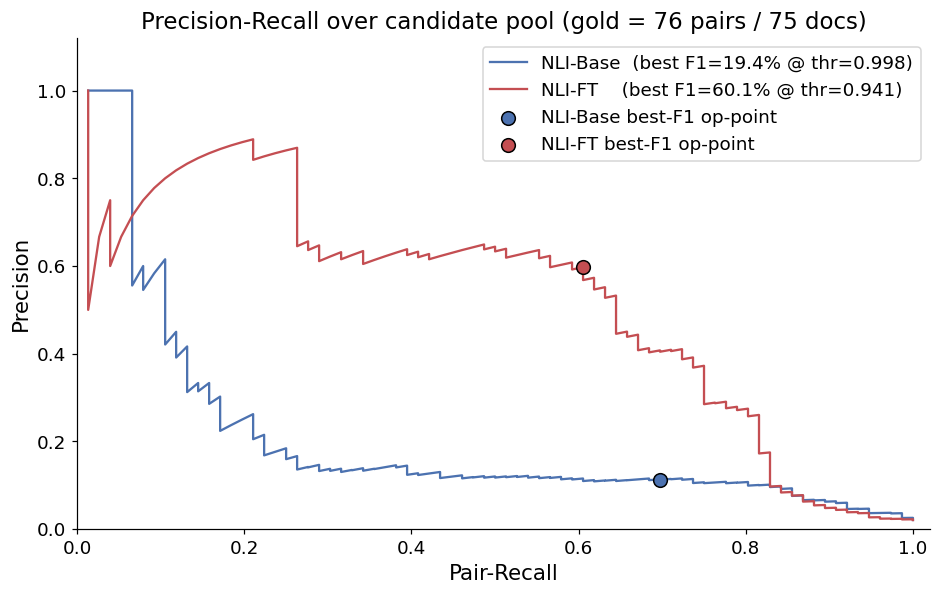

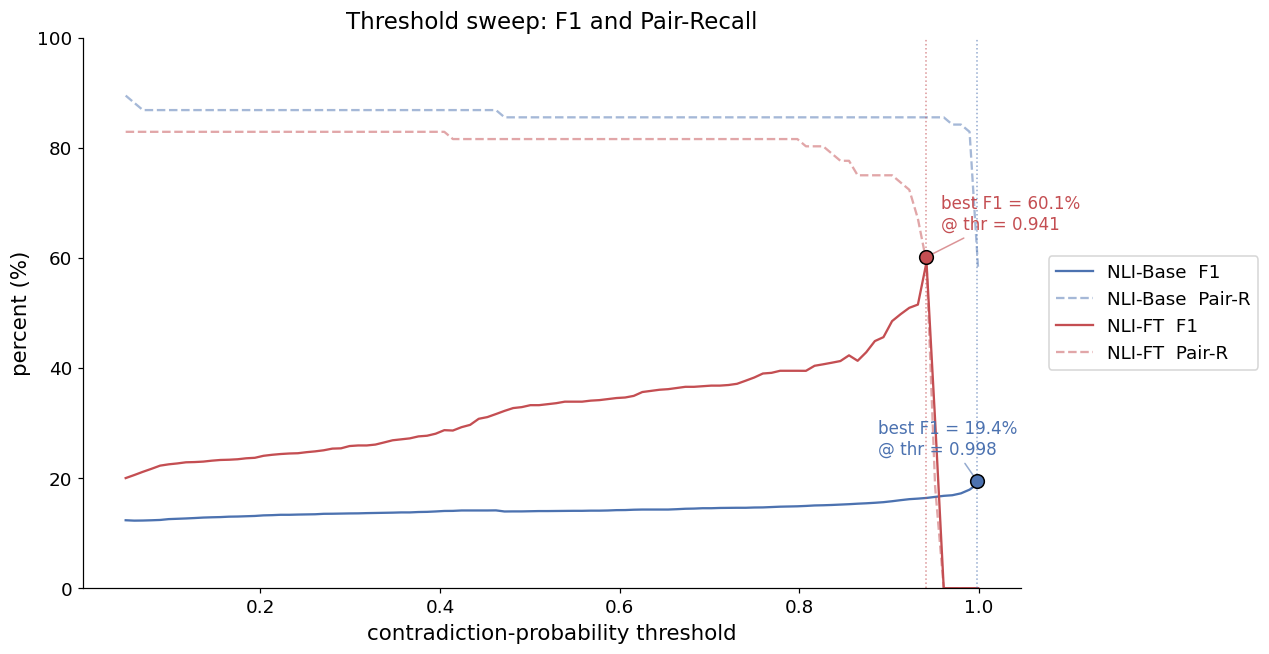

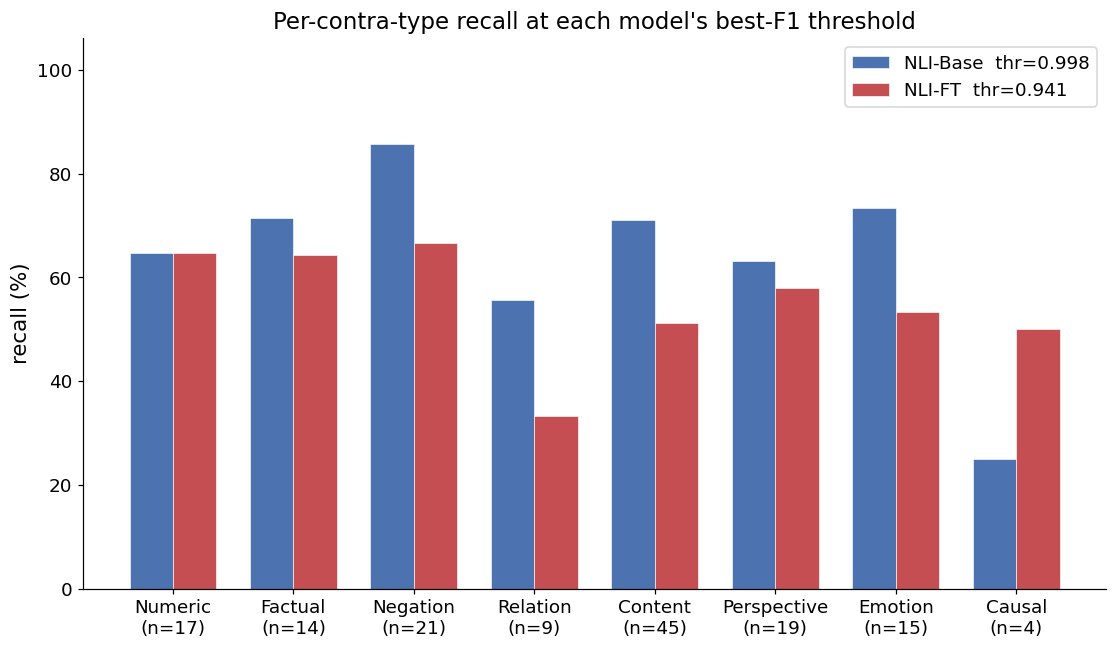

Saved 3 plots to D:\AT82.05-Claim-Contradiction-Over-Knowledge-Graphs\experiments\plots\06_NLI


In [11]:
import matplotlib.pyplot as plt

PLOT_DIR = Path("plots/06_NLI")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 13,
    "axes.titlesize": 15,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.titlesize": 15,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

C_BLUE, C_RED, C_GREEN, C_PURPLE, C_YELLOW = "#4C72B0", "#C44E52", "#55A868", "#8172B2", "#CCB974"


def pr_curve(scores: np.ndarray, gold: np.ndarray):
    """Sweep threshold over unique score values; return (precision, recall) arrays."""
    order = np.argsort(-scores)
    g = gold[order]
    tp = np.cumsum(g)
    fp = np.cumsum(~g)
    prec = tp / np.maximum(tp + fp, 1)
    rec = tp / max(int(gold.sum()), 1)
    return prec, rec


# --- Plot 1: PR curve (Base vs FT) ---
b_prec, b_rec = pr_curve(base_contra, is_gold)
f_prec, f_rec = pr_curve(ft_contra, is_gold)
fig, ax = plt.subplots(figsize=(10, 5.8))
ax.plot(b_rec, b_prec, color=C_BLUE, label=f"NLI-Base  (best F1={bb['f1']:.1%} @ thr={bb['thr']:.3f})")
ax.plot(f_rec, f_prec, color=C_RED,  label=f"NLI-FT    (best F1={bf['f1']:.1%} @ thr={bf['thr']:.3f})")
ax.scatter([bb["pair_r"]], [bb["prec"]], s=80, color=C_BLUE, edgecolor="black", zorder=5, label=f"NLI-Base best-F1 op-point")
ax.scatter([bf["pair_r"]], [bf["prec"]], s=80, color=C_RED,  edgecolor="black", zorder=5, label=f"NLI-FT best-F1 op-point")
ax.set_xlabel("Pair-Recall")
ax.set_ylabel("Precision")
ax.set_title(f"Precision-Recall over candidate pool (gold = {n_total_gold} pairs / {n_gold_docs} docs)")
ax.legend(loc="upper right")
ax.set_xlim(0, 1.02)
ax.set_ylim(0, max(b_prec.max(), f_prec.max()) * 1.1 + 0.02)
fig.savefig(PLOT_DIR / "pr_curve.png")
plt.show()

# --- Plot 2: F1 / Pair-R / Doc-R / Precision vs threshold ---
thr_grid = np.linspace(0.05, 0.999, 100)


def metrics_grid(scores: np.ndarray):
    f1, pr = [], []
    for t in thr_grid:
        pred = scores >= t
        tp = int((pred & is_gold).sum())
        fp = int((pred & ~is_gold).sum())
        fn = int((~pred & is_gold).sum())
        p = tp / max(tp + fp, 1); r = tp / max(tp + fn, 1)
        f1.append(2 * p * r / max(p + r, 1e-9))
        pr.append(r)
    return np.array(f1), np.array(pr)


bf1, bpr = metrics_grid(base_contra)
ff1, fpr = metrics_grid(ft_contra)

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.plot(thr_grid, bf1 * 100, color=C_BLUE, label="NLI-Base  F1")
ax.plot(thr_grid, bpr * 100, color=C_BLUE, linestyle="--", alpha=0.5, label="NLI-Base  Pair-R")
ax.plot(thr_grid, ff1 * 100, color=C_RED,  label="NLI-FT  F1")
ax.plot(thr_grid, fpr * 100, color=C_RED,  linestyle="--", alpha=0.5, label="NLI-FT  Pair-R")

# Mark best-F1 points + dashed verticals + threshold annotations near the x-axis
for d, color, label in [(bb, C_BLUE, "Base"), (bf, C_RED, "FT")]:
    ax.axvline(d["thr"], color=color, linestyle=":", linewidth=1.0, alpha=0.6)
    ax.scatter([d["thr"]], [d["f1"] * 100], s=80, color=color, edgecolor="black", zorder=5)
    ax.annotate(
        f"best F1 = {d['f1']:.1%}\n@ thr = {d['thr']:.3f}",
        xy=(d["thr"], d["f1"] * 100),
        xytext=(-65, 18) if label == "Base" else (10, 18),
        textcoords="offset points",
        fontsize=11, color=color,
        arrowprops=dict(arrowstyle="-", color=color, alpha=0.6),
    )

ax.set_xlabel("contradiction-probability threshold")
ax.set_ylabel("percent (%)")
ax.set_title("Threshold sweep: F1 and Pair-Recall")
ax.set_ylim(0, 100)
# Move legend OUTSIDE the axes (right side) so it never overlaps the lines.
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
fig.savefig(PLOT_DIR / "threshold_sweep.png")
plt.show()

# --- Plot 3: per-contra-type recall at best-F1 thresholds ---
type_order = ["Numeric", "Factual", "Negation", "Relation", "Content", "Perspective/View/Opinion", "Emotion/Mood/Feeling", "Causal"]
type_totals = {t: 0 for t in type_order}
for p in gold_set:
    for t in doc_types.get(p[0][0], []):
        if t in type_totals:
            type_totals[t] += 1


def recall_for(flagged):
    caught = {t: 0 for t in type_order}
    for p in gold_set:
        if p in flagged:
            for t in doc_types.get(p[0][0], []):
                if t in caught:
                    caught[t] += 1
    return [caught[t] / max(type_totals[t], 1) * 100 for t in type_order]


base_rec_t = recall_for(base_flagged)
ft_rec_t   = recall_for(ft_flagged)
x = np.arange(len(type_order))
w = 0.36
fig, ax = plt.subplots(figsize=(12, 6.5))
ax.bar(x - w / 2, base_rec_t, w, label=f"NLI-Base  thr={base_thr:.3f}", color=C_BLUE, edgecolor="white", linewidth=0.4)
ax.bar(x + w / 2, ft_rec_t,   w, label=f"NLI-FT  thr={ft_thr:.3f}",     color=C_RED,  edgecolor="white", linewidth=0.4)
short = {"Perspective/View/Opinion": "Perspective", "Emotion/Mood/Feeling": "Emotion"}
ax.set_xticks(x)
ax.set_xticklabels([f"{short.get(t, t)}\n(n={type_totals[t]})" for t in type_order], rotation=0)
ax.set_ylabel("recall (%)")
ax.set_title("Per-contra-type recall at each model's best-F1 threshold")
ymax = max(max(base_rec_t, default=0), max(ft_rec_t, default=0))
ax.set_ylim(0, ymax * 1.18 + 5)
ax.legend(loc="upper right")
fig.savefig(PLOT_DIR / "per_type_recall.png")
plt.show()

print(f"Saved 3 plots to {PLOT_DIR.resolve()}")